In [1]:
#Youtube video link: https://youtu.be/lkPSmzFeNvI?si=0w0Y6B01kL2mU84m

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv("Customer.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Customer.csv'

In [32]:
df["Churn"].unique()

array([ 1.,  0., nan])

In [34]:
df.isnull().sum()

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

In [36]:
df.shape

(440833, 12)

In [38]:
df[df["Gender"].isnull()]

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
199295,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [40]:
# Fix: Drop rows where "Gender" is null across the whole dataframe
df = df.dropna(subset=["Gender"])  

In [42]:
df.isnull().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [44]:
df["Gender"].unique()

array(['Female', 'Male'], dtype=object)

# EDA

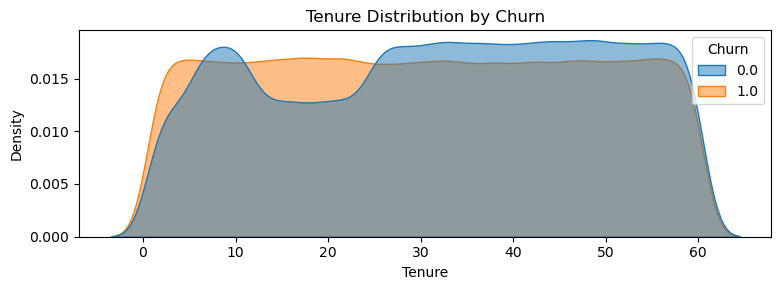

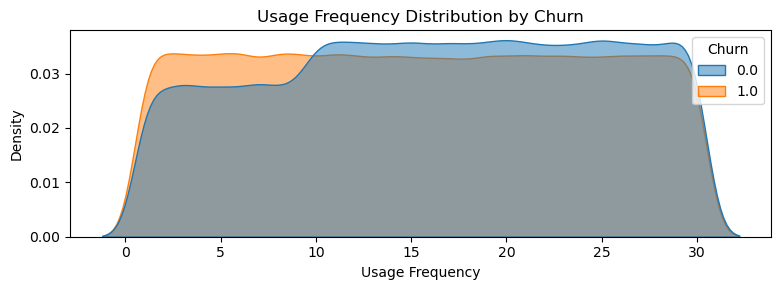

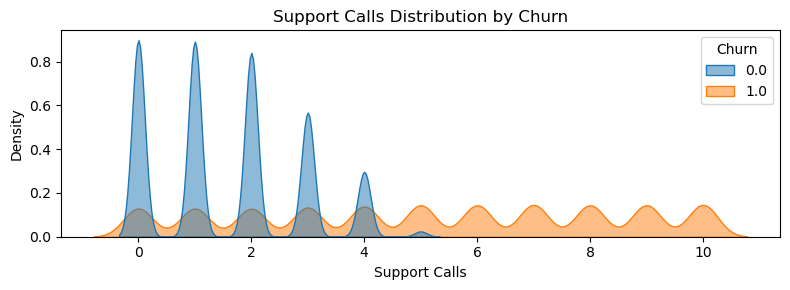

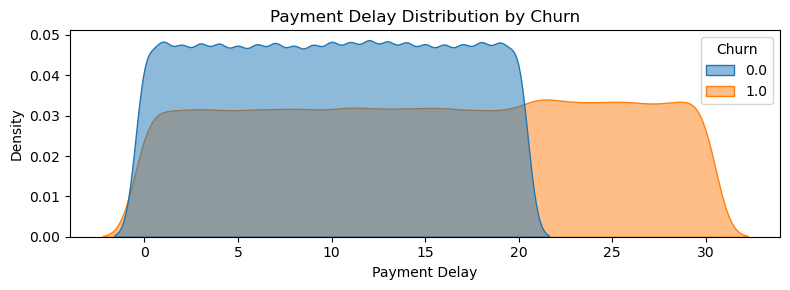

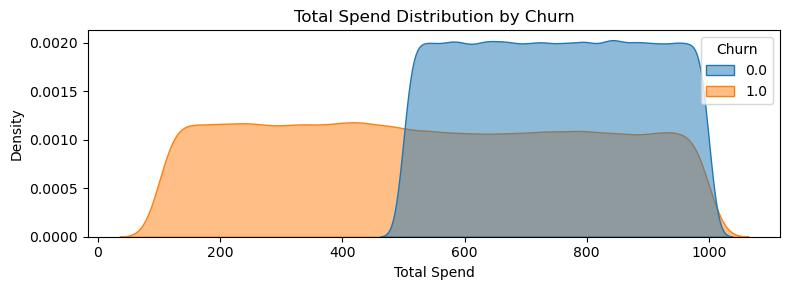

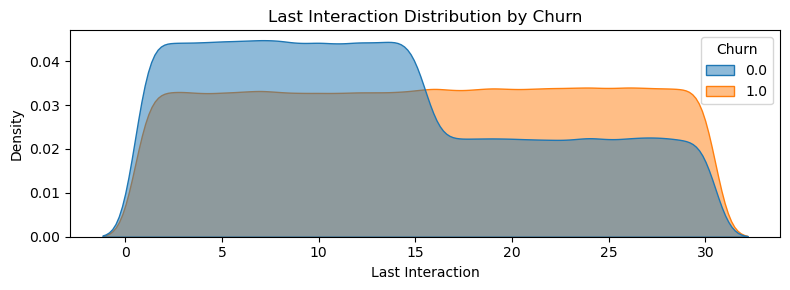

In [72]:
num_cols = ['Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction']

# --- Distribution plots
for col in num_cols:
    plt.figure(figsize=(8,3))
    sns.kdeplot(data=df, x=col, hue='Churn', fill=True, common_norm=False, alpha=0.5)
    plt.title(f'{col} Distribution by Churn')
    plt.tight_layout()
    plt.show()

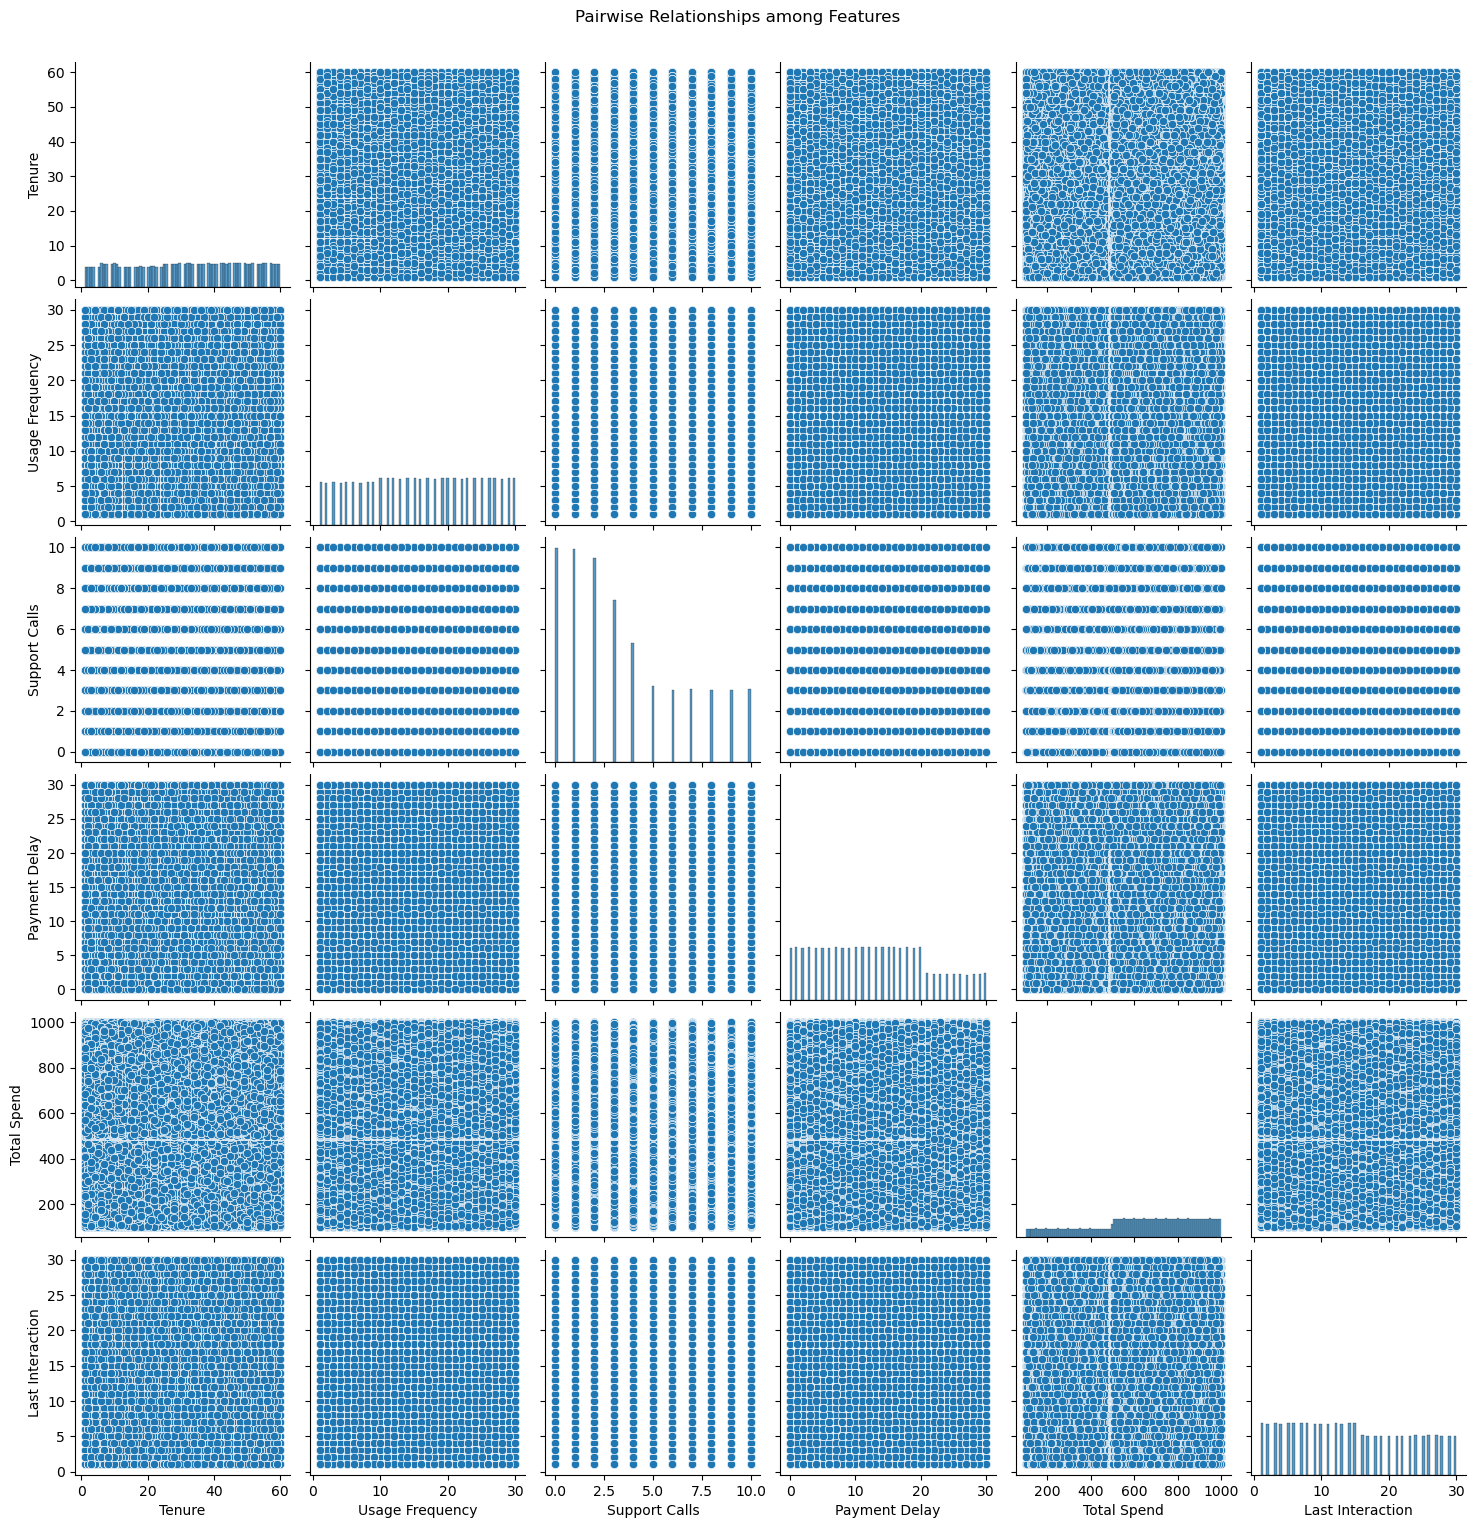

In [80]:
# --- Pairplot (sampled for speed)
sns.pairplot(df[['Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction']])
plt.suptitle('Pairwise Relationships among Features', y=1.02)
plt.show()

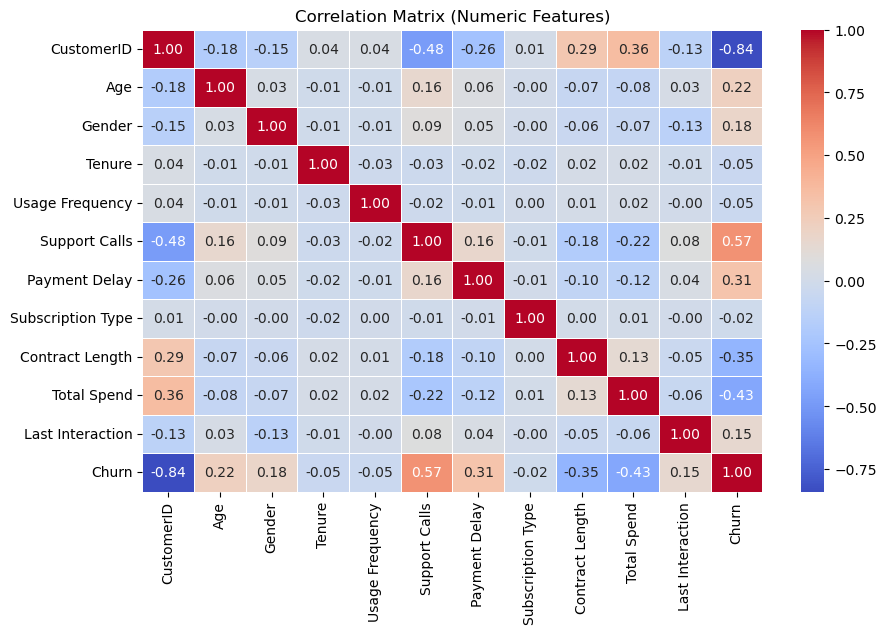

In [84]:
# --- Heatmap visualization
corr = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix (Numeric Features)')
plt.show()

# Data Encoding

In [47]:

df = df.replace({
    'Gender': {
        'Male': 0, 
        'Female': 1
    },
    'Subscription Type': {
        'Basic': 0, 
        'Standard': 1, 
        'Premium': 2
    },
    'Contract Length': {
        'Monthly': 0, 
        'Quarterly': 1, 
        'Annual': 2
    }
})

In [49]:

X=df.drop(["Churn", "CustomerID"],axis=1)
y=df["Churn"]

In [51]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.3, random_state=42)

In [54]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()

rf_params = {"max_depth": [3,5,10],
             "max_features": [5, 7, 8],
             "min_samples_split": [2, 5],
             "n_estimators": [10,50]}

from sklearn.model_selection import RandomizedSearchCV
random = RandomizedSearchCV(estimator=model, param_distributions=rf_params, cv=2, verbose=0)
random.fit(X_train, y_train)



RandomizedSearchCV(cv=2, estimator=RandomForestClassifier(),
                   param_distributions={'max_depth': [3, 5, 10],
                                        'max_features': [5, 7, 8],
                                        'min_samples_split': [2, 5],
                                        'n_estimators': [10, 50]})

In [56]:
print(random.best_params_ )

{'n_estimators': 10, 'min_samples_split': 2, 'max_features': 7, 'max_depth': 10}


In [60]:
y_pred=random.predict(X_test)
y_pred

array([1., 1., 1., ..., 1., 0., 1.])

# Performance Metrics

In [63]:
from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay, \
                            precision_score, recall_score, f1_score, roc_auc_score,roc_curve 

#3)Performance metric (always between y_pred and y_test)
model_test_accuracy = accuracy_score(y_test, y_pred) # Calculate Accuracy
model_test_f1 = f1_score(y_test, y_pred, average='weighted') # Calculate F1-score
model_test_precision = precision_score(y_test, y_pred) # Calculate Precision
model_test_recall = recall_score(y_test, y_pred) # Calculate Recall
model_test_rocauc_score = roc_auc_score(y_test, y_pred) #Calculate Roc

print('Model performance for Test set')
print('- Accuracy: {:.4f}'.format(model_test_accuracy))
print('- F1 score: {:.4f}'.format(model_test_f1))
print('- Precision: {:.4f}'.format(model_test_precision))
print('- Recall: {:.4f}'.format(model_test_recall))
print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))

Model performance for Test set
- Accuracy: 0.9969
- F1 score: 0.9969
- Precision: 1.0000
- Recall: 0.9946
- Roc Auc Score: 0.9973


<Axes: >

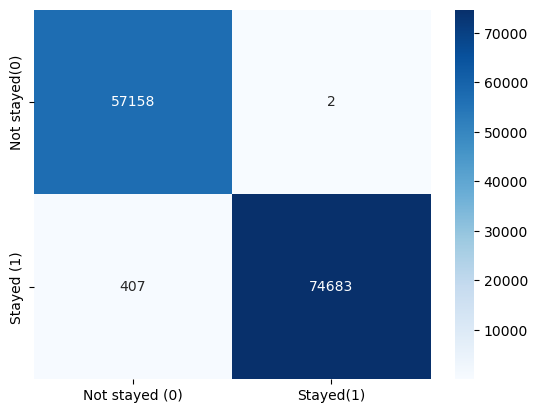

In [65]:
#Visualisation for classification models generally
from sklearn.metrics import confusion_matrix

# 1. Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 2. Plot it nicely using Seaborn
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not stayed (0)', 'Stayed(1)'], 
            yticklabels=['Not stayed(0)', 'Stayed (1)'])